# HW02 — Hourly Wikipedia events directly from S3

Read all 24 hourly Parquet objects from my private bucket, combine the events, and plot total and per-type hourly counts. All input discovery and reads use S3. Figures are exported as PNG and SVG.


In [1]:
from pathlib import Path
from zoneinfo import ZoneInfo

import boto3
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import pandas as pd
import seaborn as sns

BUCKET = "dsan6000-bz263"
PREFIX = "wikipedia-hourly/"
TIMEZONE = "America/New_York"
s3 = boto3.client("s3", region_name="us-east-1")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 180, "svg.fonttype": "none"})
IMAGE_DIR = Path("images")
IMAGE_DIR.mkdir(exist_ok=True)

In [2]:
pages = s3.get_paginator("list_objects_v2").paginate(Bucket=BUCKET, Prefix=PREFIX)
keys = sorted(
    obj["Key"] for page in pages for obj in page.get("Contents", [])
    if obj["Key"].endswith(".parquet")
)
assert len(keys) == 24, f"Expected 24 hourly objects, found {len(keys)}."

hourly_frames = []
for key in keys:
    hour_df = pd.read_parquet(f"s3://{BUCKET}/{key}", engine="pyarrow")
    hourly_frames.append(hour_df)

events = pd.concat(hourly_frames, ignore_index=True)
del hourly_frames, hour_df
print(f"Loaded {len(keys)} S3 objects and {len(events):,} events.")
print(f"Columns: {list(events.columns)}")
events.head()

Loaded 24 S3 objects and 119,708 events.
Columns: ['datetime', '$schema', 'meta', 'id', 'type', 'namespace', 'title', 'title_url', 'comment', 'timestamp', 'user', 'bot', 'notify_url', 'minor', 'length', 'revision', 'server_url', 'server_name', 'server_script_path', 'wiki', 'parsedcomment', 'log_id', 'log_type', 'log_action', 'log_params', 'log_action_comment', 'patrolled', 'file_ts', 'file_ts_str']


,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


## Time and count validation

`timestamp` is Unix time in seconds. Convert it to UTC first, then to America/New_York (EDT for these dates). Count rows with `groupby().size()` so missing values in unrelated columns cannot reduce the count. Check each event against its supplied `file_ts` hourly label, including the ISO date-only representation used at midnight.


In [3]:
assert {"timestamp", "type", "file_ts"}.issubset(events.columns)
assert events[["timestamp", "type", "file_ts"]].notna().all().all()

events["event_time"] = pd.to_datetime(events["timestamp"], unit="s", utc=True).dt.tz_convert(TIMEZONE)
events["hour"] = events["event_time"].dt.floor("h")
file_hours = pd.to_datetime(events["file_ts"], format="ISO8601", utc=True).dt.tz_convert(TIMEZONE)
assert events["hour"].eq(file_hours).all(), "An event's hour differs from its source file label."

hours = pd.date_range(events["hour"].min(), events["hour"].max(), freq="h", name="hour")
assert len(hours) == 24 and events["hour"].nunique() == 24

hourly_counts = (
    events.groupby("hour").size().reindex(hours, fill_value=0)
    .rename("event_count").reset_index()
)
event_types = sorted(events["type"].unique())
complete_index = pd.MultiIndex.from_product([hours, event_types], names=["hour", "type"])
counts_by_type = (
    events.groupby(["hour", "type"]).size().reindex(complete_index, fill_value=0)
    .rename("event_count").reset_index()
)
assert hourly_counts["event_count"].sum() == len(events)
assert counts_by_type["event_count"].sum() == len(events)
assert counts_by_type.groupby("hour")["event_count"].sum().eq(
    hourly_counts.set_index("hour")["event_count"]
).all()

print(f"Observed event range: {events['event_time'].min()} to {events['event_time'].max()}")
print("Total events by type:")
print(events["type"].value_counts().to_string())
hourly_counts

Observed event range: 2026-09-01 00:00:01-04:00 to 2026-09-01 23:44:54-04:00
Total events by type:
type
edit    110896
new       4411
log       4401


,hour,event_count
0,2026-09-01 00:00:00-04:00,4458
1,2026-09-01 01:00:00-04:00,3769
2,2026-09-01 02:00:00-04:00,3981
3,2026-09-01 03:00:00-04:00,3186
4,2026-09-01 04:00:00-04:00,3519
5,2026-09-01 05:00:00-04:00,3316
6,2026-09-01 06:00:00-04:00,3654
7,2026-09-01 07:00:00-04:00,4056
8,2026-09-01 08:00:00-04:00,4599
9,2026-09-01 09:00:00-04:00,6200


## Interpretation

The extracts contain **119,708 events**: 110,896 edits, 4,411 new-page events, and 4,401 log events. The highest hourly count is **6,902 at 17:00 EDT**; the lowest is **3,186 at 03:00 EDT**. Edits dominate throughout the day.

The final extract's latest observed event is **23:44:54 EDT**, so the 23:00 point should not be interpreted as a verified full hour of collection. The following final two code cells each display one Seaborn line plot and export both required formats.


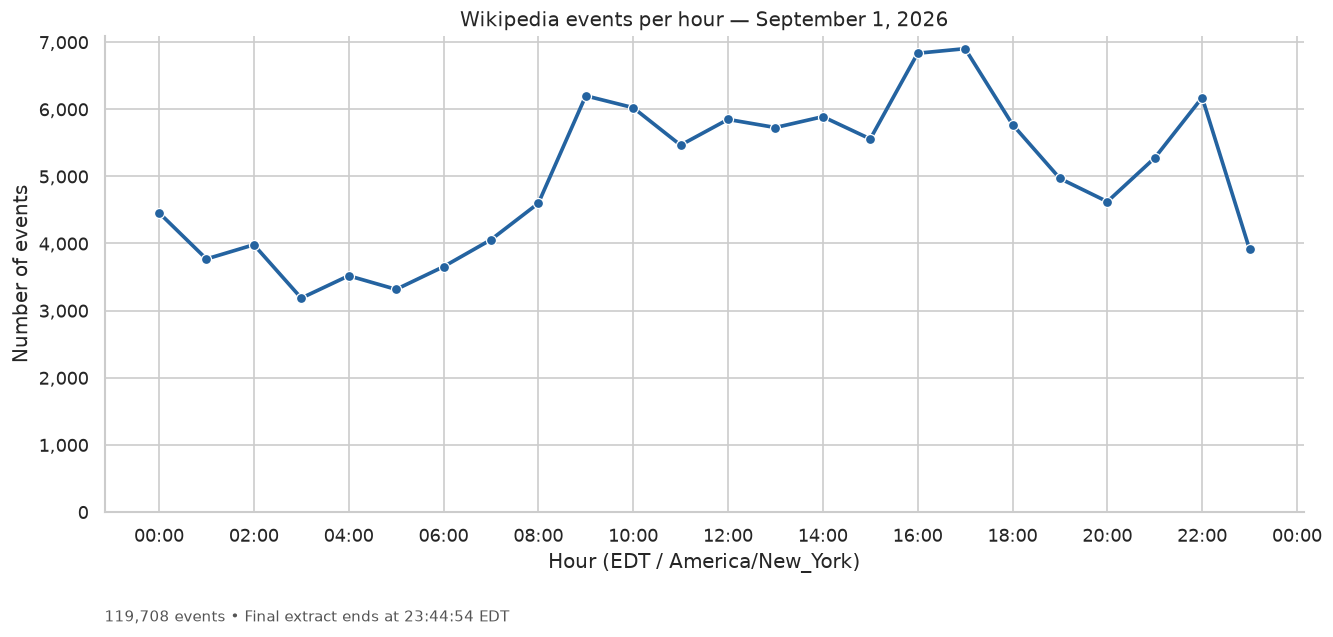

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.2), layout="constrained")
sns.lineplot(data=hourly_counts, x="hour", y="event_count", estimator=None,
             errorbar=None, marker="o", linewidth=2.2, color="#2463A0", ax=ax)
ax.set(title="Wikipedia events per hour — September 1, 2026",
       xlabel="Hour (EDT / America/New_York)", ylabel="Number of events", ylim=(0, None))
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 2), tz=ZoneInfo(TIMEZONE)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=ZoneInfo(TIMEZONE)))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.text(0, -0.23, "119,708 events • Final extract ends at 23:44:54 EDT",
        transform=ax.transAxes, fontsize=9, color="#555555")
sns.despine(ax=ax)
for extension in ("png", "svg"):
    fig.savefig(IMAGE_DIR / f"hourly-events.{extension}", bbox_inches="tight")
plt.show()

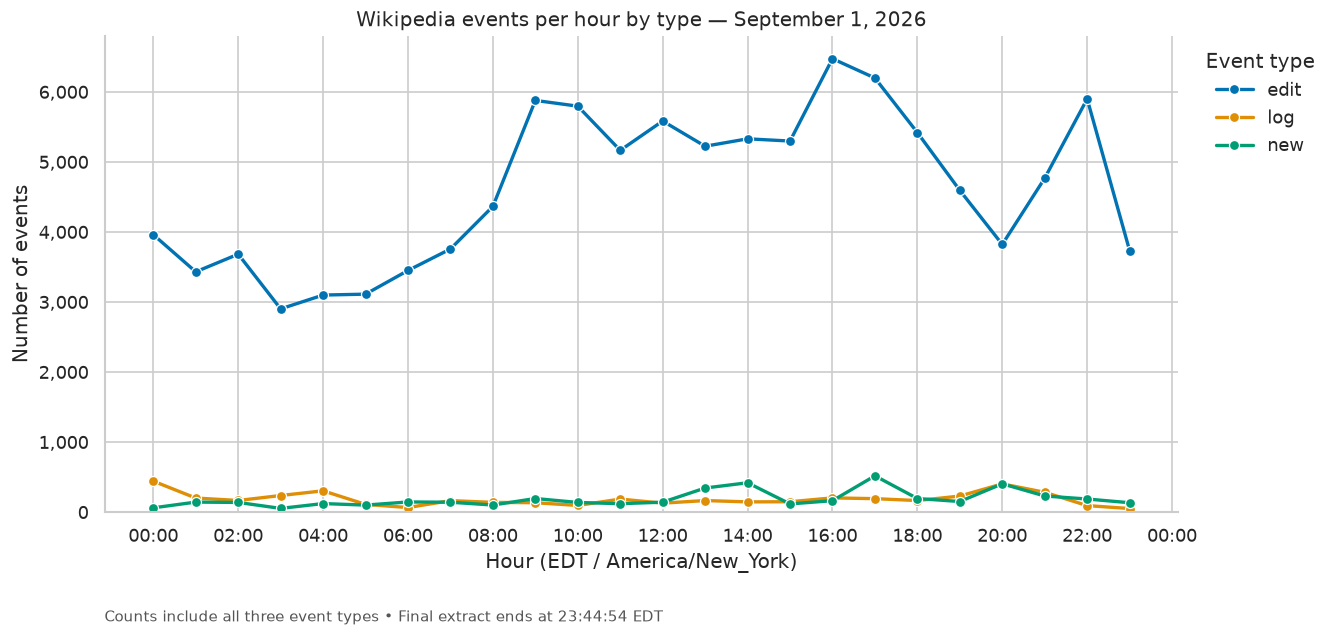

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.2), layout="constrained")
sns.lineplot(data=counts_by_type, x="hour", y="event_count", hue="type",
             hue_order=event_types, palette="colorblind", estimator=None, errorbar=None,
             marker="o", linewidth=2.0, ax=ax)
ax.set(title="Wikipedia events per hour by type — September 1, 2026",
       xlabel="Hour (EDT / America/New_York)", ylabel="Number of events", ylim=(0, None))
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 2), tz=ZoneInfo(TIMEZONE)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=ZoneInfo(TIMEZONE)))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(title="Event type", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
ax.text(0, -0.23, "Counts include all three event types • Final extract ends at 23:44:54 EDT",
        transform=ax.transAxes, fontsize=9, color="#555555")
sns.despine(ax=ax)
for extension in ("png", "svg"):
    fig.savefig(IMAGE_DIR / f"events-by-type.{extension}", bbox_inches="tight")
plt.show()